<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 2</h3>
    <h3>Ejercicio 1</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

In [ ]:
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###
# PARA QUE PUEDA CORRER LA LIBRARIA PMDARIMA HAY QUE INSTALAR LAS SIGUIENTES VERSIONES.
# SINO, HAY PROBLEMAS DE COMPATIBILIDADES ( OTRA SOLUCION SERIA INSTALAR OTRA VERSION DE PYTHON)
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###


!pip install numpy==1.26.4 pandas==2.2.2 statsmodels==0.14.4 pmdarima==2.0.4
!pip install scipy==1.13.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.6
    Uninstalling statsmodels-0.14.6:
      Successfully uninstalled statsmodels-0.14.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 35.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.1 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatib

In [ ]:
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###
# ESTA NOTEBOOK FUE AGREGADA .
# AQUI IMPORTO LA LIBRERIA
# FUENTE : https://alkaline--ml-com.translate.goog/pmdarima/modules/generated/pmdarima.arima.auto_arima.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###

import pmdarima as pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.arima_process import arma_generate_sample
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

from itertools import product

plt.rcParams['figure.figsize'] = (10, 5)
from statsmodels.tsa.arima_process import ArmaProcess

# **MODELO MA**

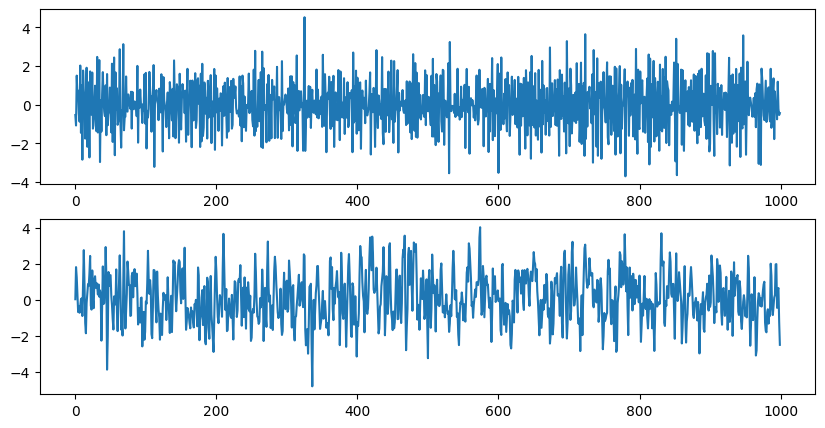

In [ ]:
# Grafico 1: MA parametro: -0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1])
ma1 = np.array([1, -0.9])
MA_object1 = ArmaProcess(ar1, ma1)
datos_simulados_1 = MA_object1.generate_sample(nsample=1000)
plt.plot(datos_simulados_1);

# Grafico 2: MA parametro: +0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1])
ma2 = np.array([1, 0.9])
MA_object2 = ArmaProcess(ar2, ma2)
datos_simulados_2 = MA_object2.generate_sample(nsample=1000)
plt.plot(datos_simulados_2);

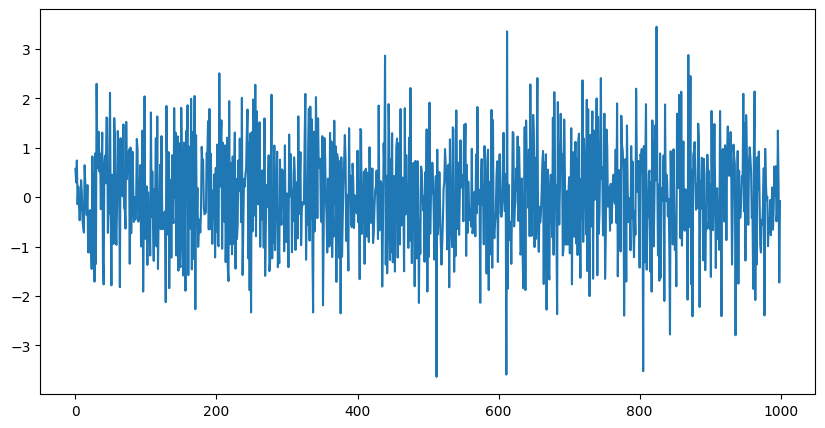

In [ ]:
# Grafico 3: MA parametro: -0.3
ar3 = np.array([1])
ma3 = np.array([1, -0.3])
MA_object3 = ArmaProcess(ar3, ma3)
datos_simulados_3 = MA_object3.generate_sample(nsample=1000)
plt.plot(datos_simulados_3);

Ambas series parecen estan centradas alrededor de 0 sin tendencias claras ni patrones ciclicos visibles.  Esto es típico de un proceso MA.

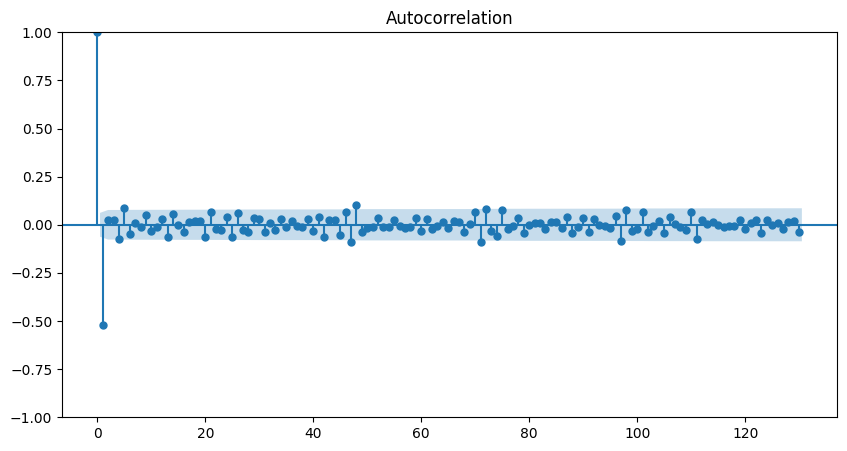

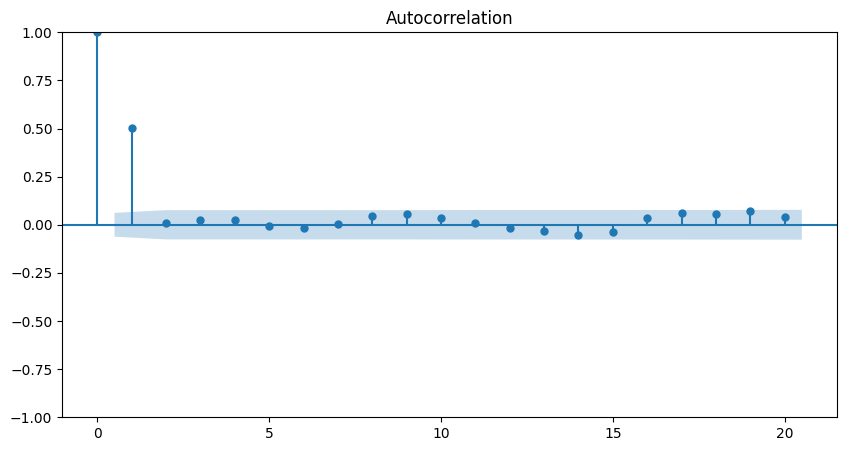

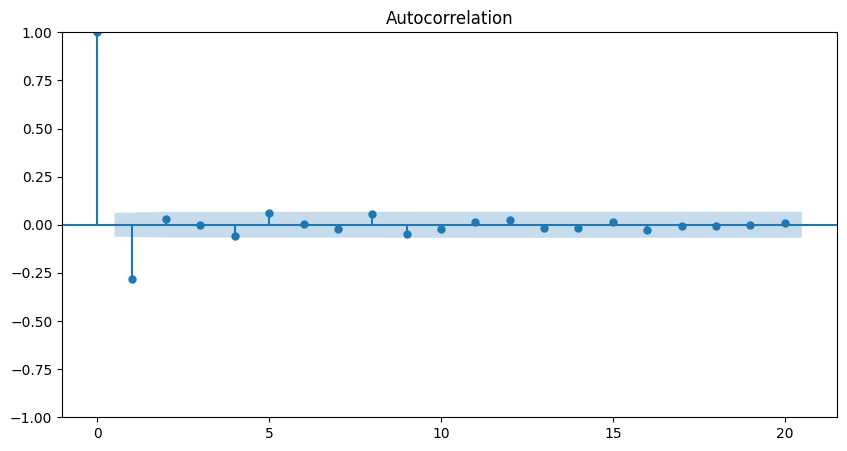

In [ ]:
# grafico ACF de los datos simulados 1:
plot_acf(datos_simulados_1, lags=130);

# grafico ACF de los datos simulados 2:
plot_acf(datos_simulados_2, lags=20);

# grafico ACF de los datos simulados 3:
plot_acf(datos_simulados_3, lags=20);

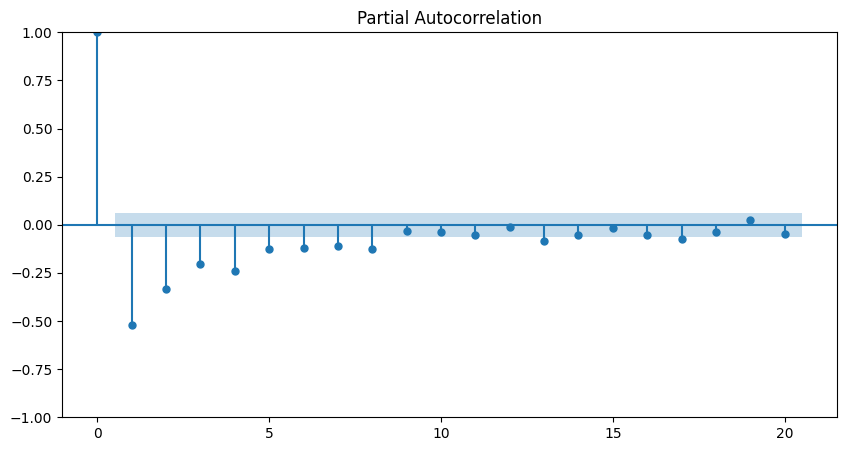

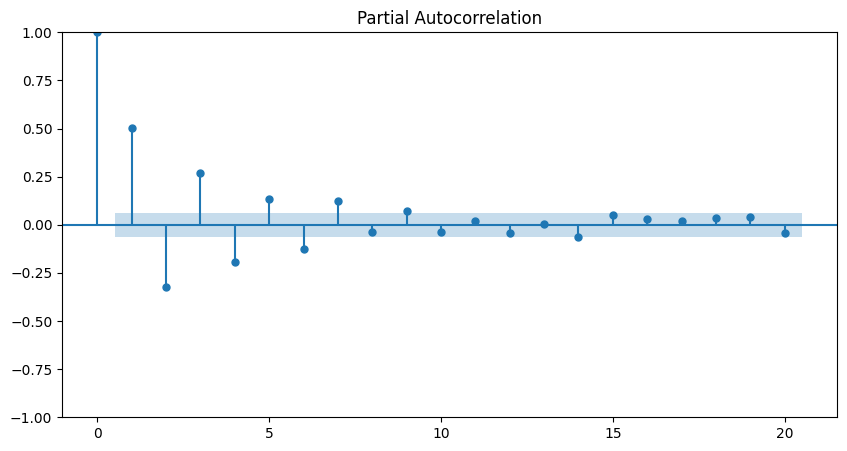

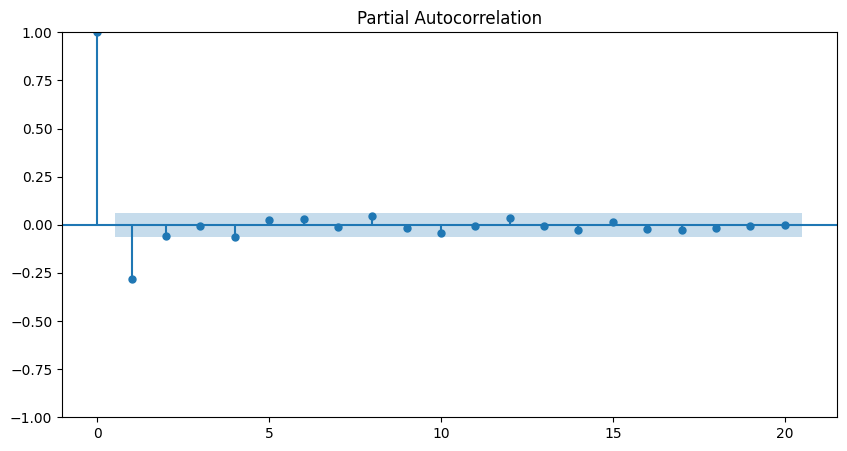

In [ ]:
# grafico PACF de los datos simulados 1:
plot_pacf(datos_simulados_1, lags=20);

# grafico PACF de los datos simulados 2:
plot_pacf(datos_simulados_2, lags=20);

# grafico PACF de los datos simulados 3:
plot_pacf(datos_simulados_3, lags=20);

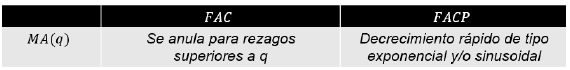

*Aqui* vemos el modelo MA(1) de los simulados 1:




In [ ]:
modelo1 = sm.tsa.arima.ARIMA(datos_simulados_1, order=(0,0,1))
resultado1 = modelo1.fit()

resultado1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1378.280
Date:                Thu, 12 Mar 2026   AIC                           2762.559
Time:                        14:43:01   BIC                           2777.283
Sample:                             0   HQIC                          2768.155
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.003      0.227      0.821      -0.006       0.008
ma.L1         -0.8865      0.015    -59.717      0.000      -0.916      -0.857
sigma2         0.9205      0.045     20.663      0.000       0.833       1.008
===================================================================================
Ljung-Box (L1) (Q):                   0.61   Jarque-Bera (JB):                 3.58
Prob(Q):                              0.44   Prob(JB):                         0.17
Heteroskedasticity (H):               1.24   Skew:                             0.02
Prob(H) (two-sided):                  0.05   Kurtosis:                         2.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

*Aqui* vemos el modelo MA(1) de los simulados 2:

In [ ]:
modelo2 = sm.tsa.arima.ARIMA(datos_simulados_2, order=(0,0,1))
resultado2 = modelo2.fit()

resultado2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1424.477
Date:                Thu, 12 Mar 2026   AIC                           2854.955
Time:                        14:43:04   BIC                           2869.678
Sample:                             0   HQIC                          2860.551
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1171      0.060      1.960      0.050    1.76e-05       0.234
ma.L1          0.8733      0.016     55.268      0.000       0.842       0.904
sigma2         1.0097      0.045     22.293      0.000       0.921       1.098
===================================================================================
Ljung-Box (L1) (Q):                   0.74   Jarque-Bera (JB):                 1.07
Prob(Q):                              0.39   Prob(JB):                         0.58
Heteroskedasticity (H):               0.89   Skew:                             0.08
Prob(H) (two-sided):                  0.31   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
modelo3 = sm.tsa.arima.ARIMA(datos_simulados_3, order=(0,0,1))
resultado3 = modelo3.fit()

resultado3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1427.693
Date:                Thu, 12 Mar 2026   AIC                           2861.386
Time:                        14:43:07   BIC                           2876.109
Sample:                             0   HQIC                          2866.982
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0308      0.023      1.365      0.172      -0.013       0.075
ma.L1         -0.2951      0.032     -9.366      0.000      -0.357      -0.233
sigma2         1.0176      0.045     22.472      0.000       0.929       1.106
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.41
Prob(Q):                              0.84   Prob(JB):                         0.82
Heteroskedasticity (H):               1.20   Skew:                            -0.05
Prob(H) (two-sided):                  0.10   Kurtosis:                         3.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# MODELO ARMA (P,Q)

- ARMA=
    - Autoregressive moving-average (ARMA) model
    - ARMA = AR + MA
        - ARMA(1, 1) model:
$$ y_t = a_1 y_{t-1} + m_1 \epsilon_{t-1} + \epsilon_t $$
        - ARMA(p, q) model:
            - p es el orden del componente AR
            - q es el orden del componente MA

ARMA (2,2)

In [ ]:
alphas = np.array([0.5, -0.25])
betas = np.array([0.5, -0.3])
ar = np.r_[1, -alphas]
ma = np.r_[1, betas]

In [ ]:
ARMA_2 = ArmaProcess(ar, ma).generate_sample(nsample=1000)


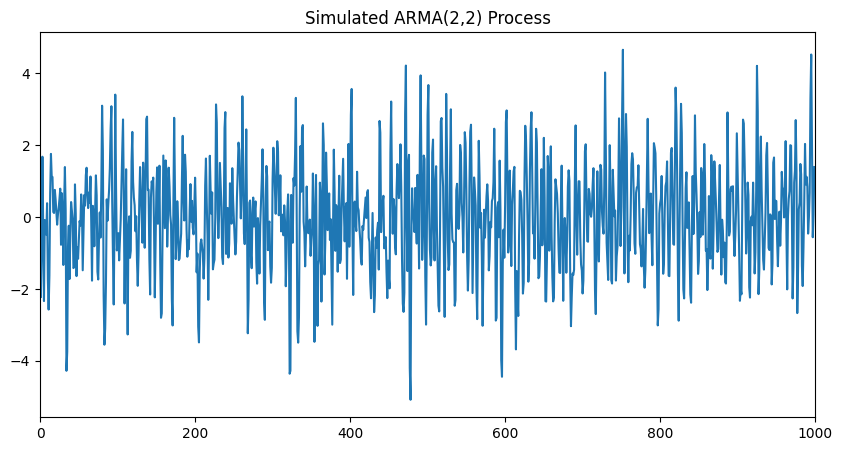

In [ ]:
plt.plot(ARMA_2)
plt.title("Simulated ARMA(2,2) Process")
plt.xlim([0, 1000])
plt.show()

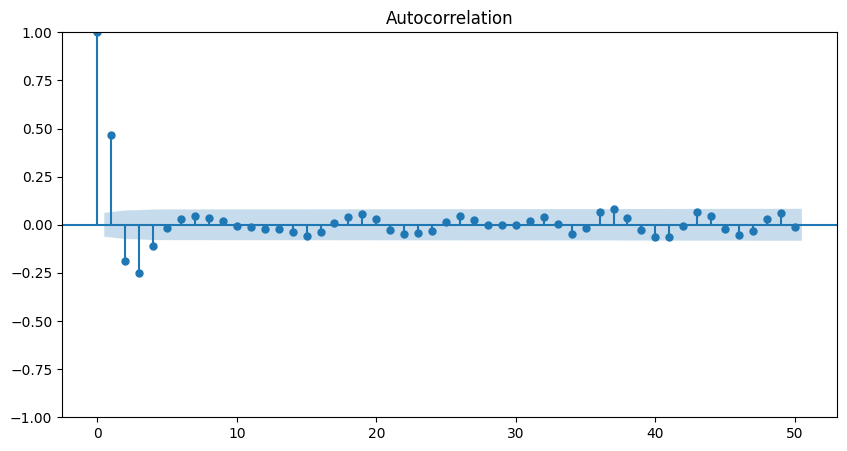

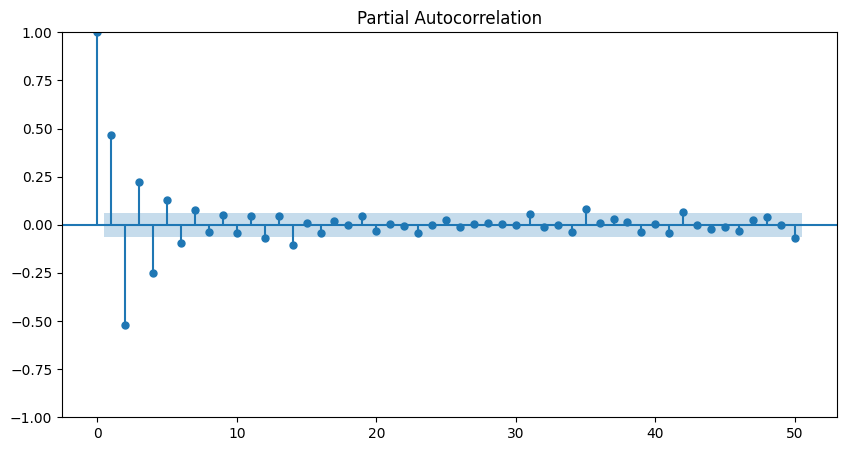

In [ ]:
plot_acf(ARMA_2, lags=50);
plot_pacf(ARMA_2, lags=50);

In [ ]:
modeloARMA_pregunta = sm.tsa.arima.ARIMA(ARMA_2, order=((1,0,1,0,1),0,2))
resultadoARMA_pregunta = modeloARMA_pregunta.fit()

resultadoARMA_pregunta.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                  
==================================================================================
Dep. Variable:                          y   No. Observations:                 1000
Model:             ARIMA([1, 3, 5], 0, 2)   Log Likelihood               -1437.295
Date:                    Thu, 12 Mar 2026   AIC                           2888.589
Time:                            14:43:28   BIC                           2922.944
Sample:                                 0   HQIC                          2901.647
                                   - 1000                                         
Covariance Type:                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.052     -0.037      0.970      -0.104       0.100
ar.L1         -0.3465      0.128     -2.712      0.007      -0.597      -0.096
ar.L3         -0.2498      0.037     -6.827      0.000      -0.322      -0.178
ar.L5         -0.0880      0.040     -2.205      0.027      -0.166      -0.010
ma.L1          1.3408      0.127     10.592      0.000       1.093       1.589
ma.L2          0.3717      0.115      3.231      0.001       0.146       0.597
sigma2         1.0356      0.043     24.097      0.000       0.951       1.120
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 5.19
Prob(Q):                              0.33   Prob(JB):                         0.07
Heteroskedasticity (H):               0.92   Skew:                             0.00
Prob(H) (two-sided):                  0.43   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
modeloARMA = sm.tsa.arima.ARIMA(ARMA_2, order=(3,0,1))
resultadoARMA = modeloARMA.fit()

resultadoARMA.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -1436.591
Date:                Thu, 12 Mar 2026   AIC                           2885.183
Time:                        14:43:32   BIC                           2914.629
Sample:                             0   HQIC                          2896.374
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0018      0.049     -0.037      0.971      -0.099       0.095
ar.L1          0.1028      0.043      2.407      0.016       0.019       0.187
ar.L2         -0.1697      0.041     -4.143      0.000      -0.250      -0.089
ar.L3         -0.1474      0.039     -3.739      0.000      -0.225      -0.070
ma.L1          0.8602      0.026     33.277      0.000       0.810       0.911
sigma2         1.0341      0.044     23.675      0.000       0.949       1.120
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.00
Prob(Q):                              0.95   Prob(JB):                         0.22
Heteroskedasticity (H):               0.91   Skew:                            -0.02
Prob(H) (two-sided):                  0.38   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###
# AQUI IMPORTAMOS LA FUNCION auto_arima .
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###

from pmdarima.arima import auto_arima

In [ ]:
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###
# AQUI CORREMOS EL "AUTOARIMA"
# PARAMETROS :
# - ARMA_2 : NOMBRE DE LA SERIE  max_order= None
# - max_p:  El valor máximo de P, inclusive que busca iterando para encontrar el modelo con el criterio de informacion mas bajo.
# - max_q: El valor máximo de Q, inclusive que busca iterando para encontrar el modelo con el criterio de informacion mas bajo.
# DE ESTA FORMA ENCONTRAMOS EL MEJOR MODELO SEGUN LOS CRITERIOS DE INFORMACION
# AQUI ESTAMOS PROBANDO MODELOS "ARMA"
### --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ###

auto_arima(ARMA_2, max_p=10, max_q=10).summary()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -1435.472
Date:                Thu, 12 Mar 2026   AIC                           2880.943
Time:                        14:43:57   BIC                           2905.482
Sample:                             0   HQIC                          2890.270
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6435      0.094      6.820      0.000       0.459       0.828
ar.L2         -0.2856      0.034     -8.301      0.000      -0.353      -0.218
ma.L1          0.3139      0.094      3.333      0.001       0.129       0.499
ma.L2         -0.4226      0.087     -4.855      0.000      -0.593      -0.252
sigma2         1.0318      0.044     23.663      0.000       0.946       1.117
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.12
Prob(Q):                              0.99   Prob(JB):                         0.21
Heteroskedasticity (H):               0.90   Skew:                            -0.02
Prob(H) (two-sided):                  0.32   Kurtosis:                         3.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

💻 Fin del codigo.